<a href="https://colab.research.google.com/github/Rohinth-KR/AMD/blob/main/Dropout.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)


In [ ]:
df = pd.read_excel("realistic_student_dropout_dataset_3000.xlsx")

print("Dataset Shape:", df.shape)
df.head()


Dataset Shape: (3000, 29)


,student_age,student_gender,parent_financial_status,parent_education_level,residence_type,daily_travel_time_minutes,college_level_achievements,physical_activity_participation,sem1_gpa,sem2_gpa,...,sem4_backlogs_count,sem1_behavior_score,sem2_behavior_score,sem3_behavior_score,sem4_behavior_score,sem1_class_interaction_score,sem2_class_interaction_score,sem3_class_interaction_score,sem4_class_interaction_score,dropout_risk
0,18,Male,Low,Low,Day Scholar,68,2,2,4.93,6.04,...,3,1.4,1.8,2.0,2.0,2.1,1.3,1.9,2.1,2
1,20,Female,Medium,Medium,Day Boarder,103,2,1,5.99,4.94,...,1,2.1,3.5,2.2,2.0,3.7,1.4,2.6,1.9,2
2,17,Male,Medium,Low,Day Scholar,75,2,1,5.95,5.41,...,3,1.6,1.6,1.8,1.9,2.0,1.3,2.4,1.8,2
3,20,Male,Medium,Medium,Day Scholar,109,0,3,4.86,4.74,...,2,3.9,3.8,4.0,2.9,3.6,4.3,3.7,3.5,2
4,19,Male,High,Medium,Day Scholar,86,1,0,6.41,6.11,...,1,2.2,1.8,1.4,1.9,1.7,2.0,1.8,2.8,2


In [ ]:
df["dropout_risk"].value_counts(normalize=True) * 100


,proportion
dropout_risk,
0,87.0
1,10.0
2,3.0


In [ ]:
X = df.drop(columns=["dropout_risk"])
y = df["dropout_risk"]

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (3000, 28)
y shape: (3000,)


In [ ]:
categorical_cols = X.select_dtypes(include="object").columns.tolist()
numerical_cols = X.select_dtypes(exclude="object").columns.tolist()

print("Categorical Columns:")
print(categorical_cols)

print("\nNumerical Columns:")
print(numerical_cols)


Categorical Columns:
['student_gender', 'parent_financial_status', 'parent_education_level', 'residence_type']

Numerical Columns:
['student_age', 'daily_travel_time_minutes', 'college_level_achievements', 'physical_activity_participation', 'sem1_gpa', 'sem2_gpa', 'sem3_gpa', 'sem4_gpa', 'sem1_attendance_percentage', 'sem2_attendance_percentage', 'sem3_attendance_percentage', 'sem4_attendance_percentage', 'sem1_backlogs_count', 'sem2_backlogs_count', 'sem3_backlogs_count', 'sem4_backlogs_count', 'sem1_behavior_score', 'sem2_behavior_score', 'sem3_behavior_score', 'sem4_behavior_score', 'sem1_class_interaction_score', 'sem2_class_interaction_score', 'sem3_class_interaction_score', 'sem4_class_interaction_score']


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("\nTrain distribution:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTest distribution:")
print(y_test.value_counts(normalize=True) * 100)


Train shape: (2400, 28)
Test shape: (600, 28)

Train distribution:
dropout_risk
0    87.0
1    10.0
2     3.0
Name: proportion, dtype: float64

Test distribution:
dropout_risk
0    87.0
1    10.0
2     3.0
Name: proportion, dtype: float64


In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numerical_cols)
    ]
)


Logistic regression

In [ ]:
log_reg = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ))
])

log_reg


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['student_gender',
                                                   'parent_financial_status',
                                                   'parent_education_level',
                                                   'residence_type']),
                                                 ('num', 'passthrough',
                                                  ['student_age',
                                                   'daily_travel_time_minutes',
                                                   'college_level_achievements',
                                                   'physical_activity_participation',
                                                   'sem1_gpa', 'sem2_gpa',
                                                   'se...
                                                   'sem2_backlogs_count',
                                                   'sem3_backlogs_count',
                                                   'sem4_backlogs_count',
                                                   'sem1_behavior_score',
                                                   'sem2_behavior_score',
                                                   'sem3_behavior_score',
                                                   'sem4_behavior_score',
                                                   'sem1_class_interaction_score',
                                                   'sem2_class_interaction_score',
                                                   'sem3_class_interaction_score',
                                                   'sem4_class_interaction_score'])])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

In [ ]:
log_reg.fit(X_train, y_train)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['student_gender',
                                                   'parent_financial_status',
                                                   'parent_education_level',
                                                   'residence_type']),
                                                 ('num', 'passthrough',
                                                  ['student_age',
                                                   'daily_travel_time_minutes',
                                                   'college_level_achievements',
                                                   'physical_activity_participation',
                                                   'sem1_gpa', 'sem2_gpa',
                                                   'se...
                                                   'sem2_backlogs_count',
                                                   'sem3_backlogs_count',
                                                   'sem4_backlogs_count',
                                                   'sem1_behavior_score',
                                                   'sem2_behavior_score',
                                                   'sem3_behavior_score',
                                                   'sem4_behavior_score',
                                                   'sem1_class_interaction_score',
                                                   'sem2_class_interaction_score',
                                                   'sem3_class_interaction_score',
                                                   'sem4_class_interaction_score'])])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

In [ ]:
y_pred_lr = log_reg.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_lr))


Accuracy: 0.8483333333333334

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.88      0.93       522
           1       0.37      0.62      0.47        60
           2       0.32      0.67      0.44        18

    accuracy                           0.85       600
   macro avg       0.56      0.72      0.61       600
weighted avg       0.91      0.85      0.87       600



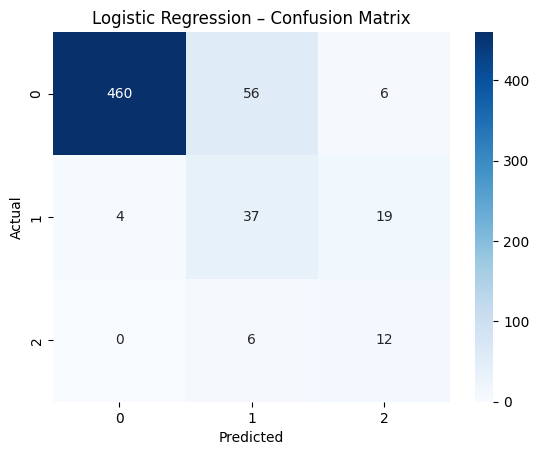

In [ ]:
cm = confusion_matrix(y_test, y_pred_lr)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression – Confusion Matrix")
plt.show()


Random Forest

In [ ]:
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    ))
])

rf_model


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['student_gender',
                                                   'parent_financial_status',
                                                   'parent_education_level',
                                                   'residence_type']),
                                                 ('num', 'passthrough',
                                                  ['student_age',
                                                   'daily_travel_time_minutes',
                                                   'college_level_achievements',
                                                   'physical_activity_participation',
                                                   'sem1_gpa', 'sem2_gpa',
                                                   'se...
                                                   'sem3_backlogs_count',
                                                   'sem4_backlogs_count',
                                                   'sem1_behavior_score',
                                                   'sem2_behavior_score',
                                                   'sem3_behavior_score',
                                                   'sem4_behavior_score',
                                                   'sem1_class_interaction_score',
                                                   'sem2_class_interaction_score',
                                                   'sem3_class_interaction_score',
                                                   'sem4_class_interaction_score'])])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced',
                                        n_estimators=200, n_jobs=-1,
                                        random_state=42))])

In [ ]:
rf_model.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['student_gender',
                                                   'parent_financial_status',
                                                   'parent_education_level',
                                                   'residence_type']),
                                                 ('num', 'passthrough',
                                                  ['student_age',
                                                   'daily_travel_time_minutes',
                                                   'college_level_achievements',
                                                   'physical_activity_participation',
                                                   'sem1_gpa', 'sem2_gpa',
                                                   'se...
                                                   'sem3_backlogs_count',
                                                   'sem4_backlogs_count',
                                                   'sem1_behavior_score',
                                                   'sem2_behavior_score',
                                                   'sem3_behavior_score',
                                                   'sem4_behavior_score',
                                                   'sem1_class_interaction_score',
                                                   'sem2_class_interaction_score',
                                                   'sem3_class_interaction_score',
                                                   'sem4_class_interaction_score'])])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced',
                                        n_estimators=200, n_jobs=-1,
                                        random_state=42))])

In [ ]:
y_pred_rf = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))


Random Forest Accuracy: 0.9033333333333333

Classification Report:

              precision    recall  f1-score   support

           0       0.92      0.99      0.95       522
           1       0.64      0.30      0.41        60
           2       0.70      0.39      0.50        18

    accuracy                           0.90       600
   macro avg       0.75      0.56      0.62       600
weighted avg       0.89      0.90      0.89       600



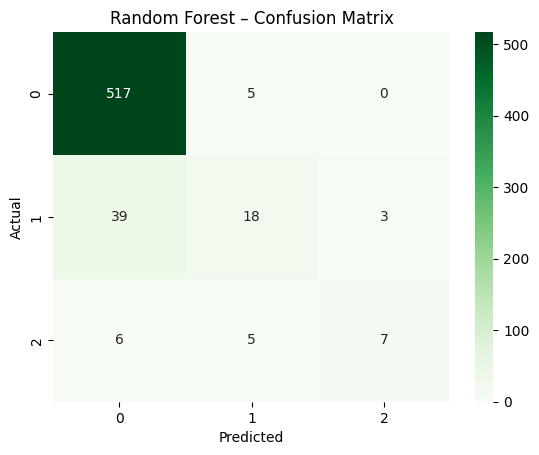

In [ ]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest – Confusion Matrix")
plt.show()


XGBoost

In [ ]:
!pip install xgboost


In [ ]:
from xgboost import XGBClassifier


In [ ]:
xgb_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="multi:softprob",
        num_class=3,
        eval_metric="mlogloss",
        random_state=42
    ))
])

xgb_model


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['student_gender',
                                                   'parent_financial_status',
                                                   'parent_education_level',
                                                   'residence_type']),
                                                 ('num', 'passthrough',
                                                  ['student_age',
                                                   'daily_travel_time_minutes',
                                                   'college_level_achievements',
                                                   'physical_activity_participation',
                                                   'sem1_gpa', 'sem2_gpa',
                                                   'se...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=6, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=300, n_jobs=None, num_class=3, ...))])

In [ ]:
xgb_model.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['student_gender',
                                                   'parent_financial_status',
                                                   'parent_education_level',
                                                   'residence_type']),
                                                 ('num', 'passthrough',
                                                  ['student_age',
                                                   'daily_travel_time_minutes',
                                                   'college_level_achievements',
                                                   'physical_activity_participation',
                                                   'sem1_gpa', 'sem2_gpa',
                                                   'se...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=6, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=300, n_jobs=None, num_class=3, ...))])

In [ ]:
y_pred_xgb = xgb_model.predict(X_test)

print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_xgb))


XGBoost Accuracy: 0.915

Classification Report:

              precision    recall  f1-score   support

           0       0.94      0.98      0.96       522
           1       0.66      0.45      0.53        60
           2       0.67      0.56      0.61        18

    accuracy                           0.92       600
   macro avg       0.76      0.66      0.70       600
weighted avg       0.90      0.92      0.91       600



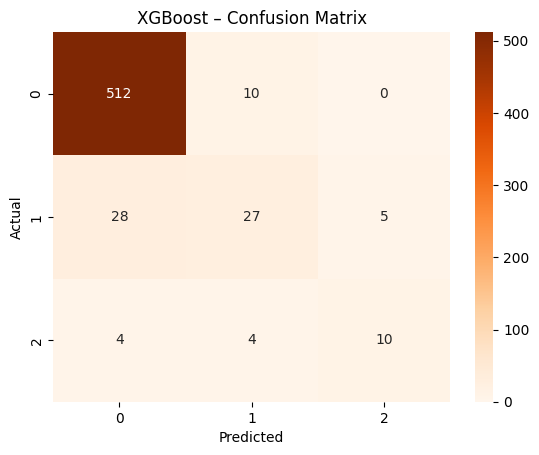

In [ ]:
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

sns.heatmap(cm_xgb, annot=True, fmt="d", cmap="Oranges")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("XGBoost – Confusion Matrix")
plt.show()


SHAP


In [ ]:
!pip install shap


In [ ]:
import shap

In [ ]:
preprocessor_fitted = xgb_model.named_steps["preprocessor"]


In [ ]:
X_train_enc = preprocessor_fitted.transform(X_train)
X_test_enc = preprocessor_fitted.transform(X_test)


In [ ]:
explainer = shap.TreeExplainer(
    xgb_model.named_steps["classifier"]
)


In [ ]:
shap_values = explainer.shap_values(X_test_enc)


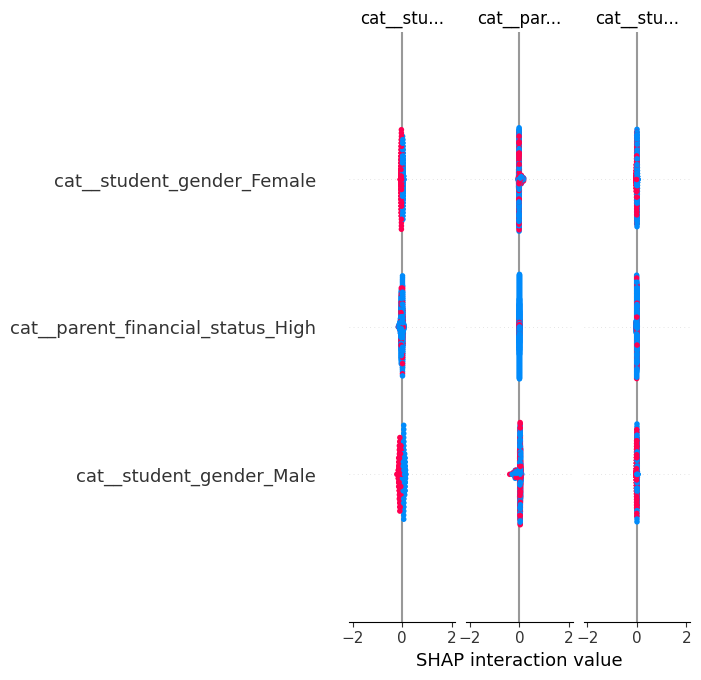

In [ ]:
shap.summary_plot(
    shap_values,
    X_test_enc,
    feature_names=preprocessor_fitted.get_feature_names_out()
)


In [ ]:
print(type(shap_values))
print(np.array(shap_values).shape)


<class 'numpy.ndarray'>
(600, 35, 3)


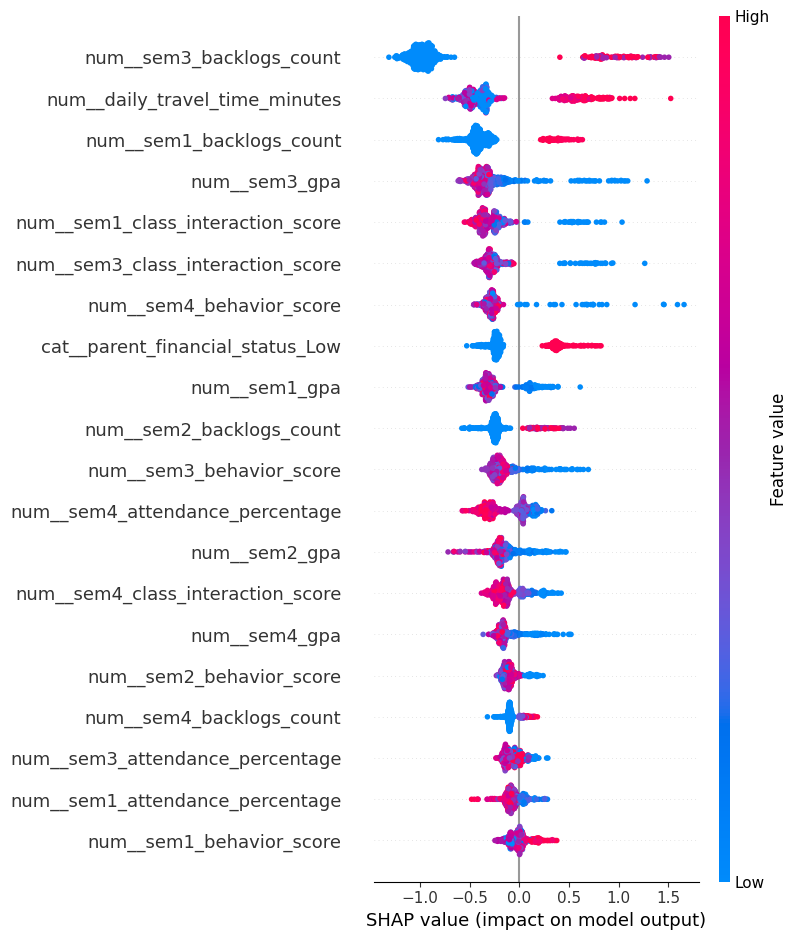

In [ ]:
shap.summary_plot(
    shap_values[:, :, 2],   # class 2 = dropout
    X_test_enc,
    feature_names=preprocessor_fitted.get_feature_names_out()
)


Testing

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    xgb_model,
    X,
    y,
    cv=skf,
    scoring="f1_macro"
)

print("Cross-validation F1-macro scores:", cv_scores)
print("Mean F1-macro:", cv_scores.mean())
print("Std deviation:", cv_scores.std())


Cross-validation F1-macro scores: [0.66551378 0.69525819 0.71397107 0.66822866 0.57143848]
Mean F1-macro: 0.662882035373358
Std deviation: 0.04910344323997592


Download Model

In [ ]:
import joblib

joblib.dump(xgb_model, "student_dropout_xgboost_model.pkl")


['student_dropout_xgboost_model.pkl']

In [ ]:
from google.colab import files
files.download("student_dropout_xgboost_model.pkl")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Manual Testing

In [ ]:
manual_student = {
    "student_age": 19,
    "student_gender": "Male",
    "parent_financial_status": "Low",
    "parent_education_level": "Medium",
    "residence_type": "Day Scholar",
    "daily_travel_time_minutes": 90,
    "college_level_achievements": 0,
    "physical_activity_participation": 1,

    "sem1_gpa": 6.2,
    "sem2_gpa": 6.0,
    "sem3_gpa": 5.6,
    "sem4_gpa": 5.4,

    "sem1_attendance_percentage": 78,
    "sem2_attendance_percentage": 72,
    "sem3_attendance_percentage": 65,
    "sem4_attendance_percentage": 68,

    "sem1_backlogs_count": 1,
    "sem2_backlogs_count": 2,
    "sem3_backlogs_count": 3,
    "sem4_backlogs_count": 1,

    "sem1_behavior_score": 2.5,
    "sem2_behavior_score": 2.2,
    "sem3_behavior_score": 2.0,
    "sem4_behavior_score": 2.1,

    "sem1_class_interaction_score": 2.8,
    "sem2_class_interaction_score": 2.4,
    "sem3_class_interaction_score": 2.0,
    "sem4_class_interaction_score": 2.1
}

manual_df = pd.DataFrame([manual_student])
manual_df


,student_age,student_gender,parent_financial_status,parent_education_level,residence_type,daily_travel_time_minutes,college_level_achievements,physical_activity_participation,sem1_gpa,sem2_gpa,...,sem3_backlogs_count,sem4_backlogs_count,sem1_behavior_score,sem2_behavior_score,sem3_behavior_score,sem4_behavior_score,sem1_class_interaction_score,sem2_class_interaction_score,sem3_class_interaction_score,sem4_class_interaction_score
0,19,Male,Low,Medium,Day Scholar,90,0,1,6.2,6.0,...,3,1,2.5,2.2,2.0,2.1,2.8,2.4,2.0,2.1


In [ ]:
prediction = xgb_model.predict(manual_df)
prediction


array([2])

In [ ]:
risk_map = {0: "Safe", 1: "Medium Risk", 2: "High Risk (Dropout)"}
print("Predicted Risk Level:", risk_map[prediction[0]])


Predicted Risk Level: High Risk (Dropout)


In [ ]:
preprocessor_fitted = xgb_model.named_steps["preprocessor"]
manual_enc = preprocessor_fitted.transform(manual_df)


In [ ]:
explainer = shap.TreeExplainer(xgb_model.named_steps["classifier"])
shap_values_manual = explainer.shap_values(manual_enc)


## SHAP-explainable AI

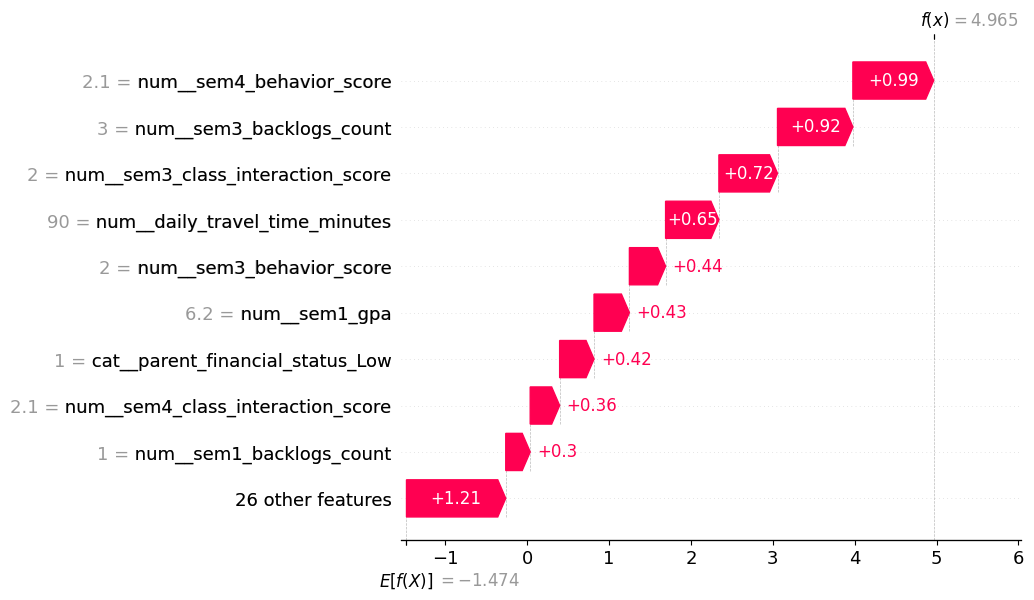

In [ ]:
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values_manual[0, :, 2],
        base_values=explainer.expected_value[2],
        data=manual_enc[0],
        feature_names=preprocessor_fitted.get_feature_names_out()
    )
)


In [ ]:
safe_student = {
    "student_age": 19,
    "student_gender": "Female",
    "parent_financial_status": "Medium",
    "parent_education_level": "High",
    "residence_type": "Day Scholar",
    "daily_travel_time_minutes": 25,
    "college_level_achievements": 3,
    "physical_activity_participation": 2,

    "sem1_gpa": 8.4,
    "sem2_gpa": 8.6,
    "sem3_gpa": 8.5,
    "sem4_gpa": 8.7,

    "sem1_attendance_percentage": 92,
    "sem2_attendance_percentage": 90,
    "sem3_attendance_percentage": 93,
    "sem4_attendance_percentage": 91,

    "sem1_backlogs_count": 0,
    "sem2_backlogs_count": 0,
    "sem3_backlogs_count": 0,
    "sem4_backlogs_count": 0,

    "sem1_behavior_score": 4.2,
    "sem2_behavior_score": 4.1,
    "sem3_behavior_score": 4.0,
    "sem4_behavior_score": 4.3,

    "sem1_class_interaction_score": 4.0,
    "sem2_class_interaction_score": 3.9,
    "sem3_class_interaction_score": 4.1,
    "sem4_class_interaction_score": 4.2
}

safe_df = pd.DataFrame([safe_student])


In [ ]:
pred_safe = xgb_model.predict(safe_df)
print("Predicted Class:", pred_safe[0])
print("Risk Level:", {0:"Safe", 1:"Medium Risk", 2:"High Risk"}[pred_safe[0]])


Predicted Class: 0
Risk Level: Safe


In [ ]:
safe_enc = preprocessor_fitted.transform(safe_df)


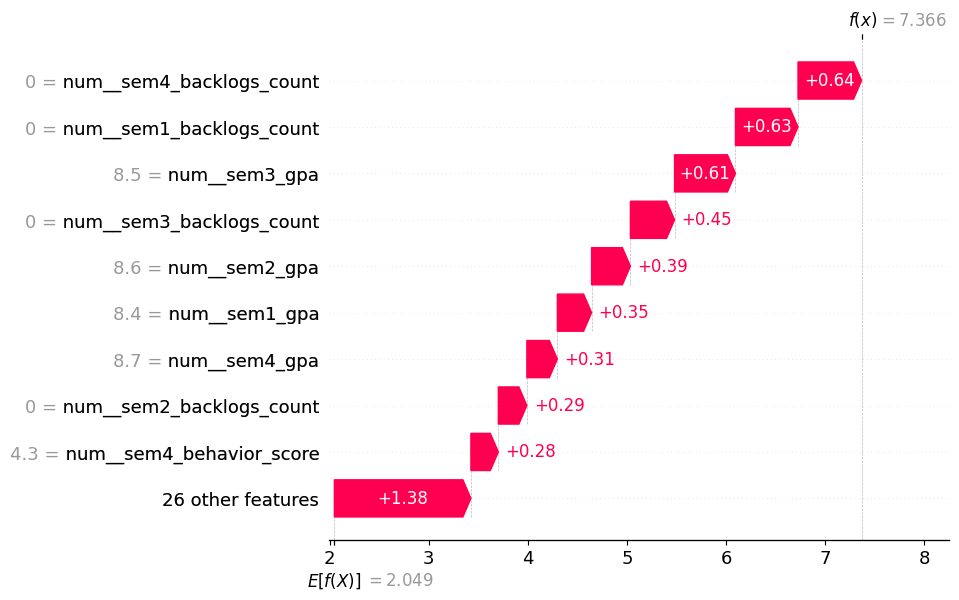

In [ ]:
shap.plots.waterfall(
    shap.Explanation(
        values=shap.TreeExplainer(
            xgb_model.named_steps["classifier"]
        ).shap_values(safe_enc)[0, :, 0],   # class 0
        base_values=explainer.expected_value[0],
        data=safe_enc[0],
        feature_names=preprocessor_fitted.get_feature_names_out()
    )
)


Model loaded successfully ✅

--- Prediction Result ---
Predicted Class: 0
Risk Level: Safe
Class Probabilities: [9.529215e-01 4.672830e-02 3.502267e-04]

Generating SHAP explanation...


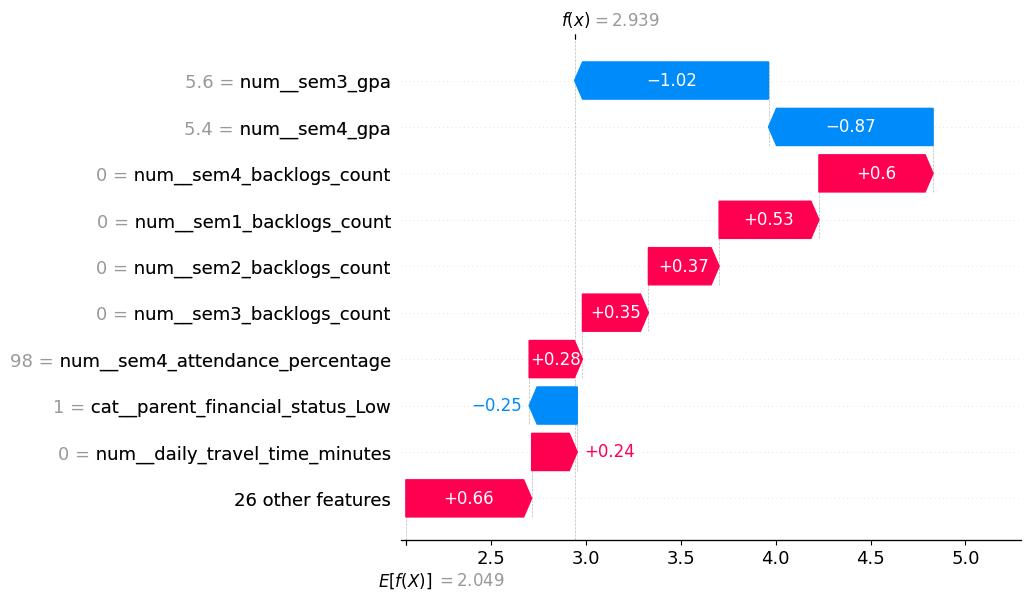


--- Textual Explanation ---
num  sem3 gpa reduced risk, num  sem4 gpa reduced risk, num  sem4 backlogs count increased risk, num  sem1 backlogs count increased risk.


In [ ]:
import pandas as pd
import joblib
import shap

def generate_text_explanation(shap_values, feature_names, top_k=4):
    """
    Converts SHAP values into a simple textual explanation
    """
    explanation = []

    # Pair features with SHAP values
    feature_impacts = list(zip(feature_names, shap_values))

    # Sort by absolute impact
    feature_impacts.sort(key=lambda x: abs(x[1]), reverse=True)

    # Take top features
    for feature, value in feature_impacts[:top_k]:
        if value > 0:
            explanation.append(f"{feature.replace('_', ' ')} increased risk")
        else:
            explanation.append(f"{feature.replace('_', ' ')} reduced risk")

    return ", ".join(explanation) + "."


# -----------------------------
# 1. LOAD TRAINED MODEL
# -----------------------------
model = joblib.load("student_dropout_xgboost_model.pkl")

preprocessor = model.named_steps["preprocessor"]
classifier = model.named_steps["classifier"]

print("Model loaded successfully ✅")

# -----------------------------
# 2. MANUAL STUDENT INPUT
# -----------------------------

manual_student = {
    "student_age": 19,
    "student_gender": "Male",
    "parent_financial_status": "Low",
    "parent_education_level": "Medium",
    "residence_type": "Day Scholar",
    "daily_travel_time_minutes": 0,
    "college_level_achievements": 2,
    "physical_activity_participation": 3,

    "sem1_gpa": 6.2,
    "sem2_gpa": 6.0,
    "sem3_gpa": 5.6,
    "sem4_gpa": 5.4,

    "sem1_attendance_percentage": 98,
    "sem2_attendance_percentage": 92,
    "sem3_attendance_percentage": 95,
    "sem4_attendance_percentage": 98,

    "sem1_backlogs_count": 0,
    "sem2_backlogs_count": 0,
    "sem3_backlogs_count": 0,
    "sem4_backlogs_count": 0,

    "sem1_behavior_score": 4.5,
    "sem2_behavior_score": 4.2,
    "sem3_behavior_score": 4.0,
    "sem4_behavior_score": 4.1,

    "sem1_class_interaction_score": 4.8,
    "sem2_class_interaction_score": 4.4,
    "sem3_class_interaction_score": 4.0,
    "sem4_class_interaction_score": 4.1
}

df = pd.DataFrame([manual_student])

# -----------------------------
# 3. PREDICTION
# -----------------------------
prediction = model.predict(df)[0]
probabilities = model.predict_proba(df)[0]

risk_map = {0: "Safe", 1: "Medium Risk", 2: "High Risk (Dropout)"}

print("\n--- Prediction Result ---")
print("Predicted Class:", prediction)
print("Risk Level:", risk_map[prediction])
print("Class Probabilities:", probabilities)

# -----------------------------
# 4. EXPLAINABLE AI (SHAP)
# -----------------------------
print("\nGenerating SHAP explanation...")

# Encode input
encoded_input = preprocessor.transform(df)

# SHAP explainer
explainer = shap.TreeExplainer(classifier)
shap_values = explainer.shap_values(encoded_input)

# Waterfall plot (STATIC, BEST FOR REPORT)
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[0, :, prediction],
        base_values=explainer.expected_value[prediction],
        data=encoded_input[0],
        feature_names=preprocessor.get_feature_names_out()
    )
)
# Generate text explanation
text_reason = generate_text_explanation(
    shap_values[0, :, prediction],
    preprocessor.get_feature_names_out()
)

print("\n--- Textual Explanation ---")
print(text_reason)


Naive Bayes

In [ ]:
from google.colab import files
uploaded = files.upload()


Saving realistic_student_dropout_dataset_3000.xlsx to realistic_student_dropout_dataset_3000.xlsx


In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report


In [ ]:
import pandas as pd

df = pd.read_excel("/content/realistic_student_dropout_dataset_3000.xlsx")
df.head()


,student_age,student_gender,parent_financial_status,parent_education_level,residence_type,daily_travel_time_minutes,college_level_achievements,physical_activity_participation,sem1_gpa,sem2_gpa,...,sem4_backlogs_count,sem1_behavior_score,sem2_behavior_score,sem3_behavior_score,sem4_behavior_score,sem1_class_interaction_score,sem2_class_interaction_score,sem3_class_interaction_score,sem4_class_interaction_score,dropout_risk
0,18,Male,Low,Low,Day Scholar,68,2,2,4.93,6.04,...,3,1.4,1.8,2.0,2.0,2.1,1.3,1.9,2.1,2
1,20,Female,Medium,Medium,Day Boarder,103,2,1,5.99,4.94,...,1,2.1,3.5,2.2,2.0,3.7,1.4,2.6,1.9,2
2,17,Male,Medium,Low,Day Scholar,75,2,1,5.95,5.41,...,3,1.6,1.6,1.8,1.9,2.0,1.3,2.4,1.8,2
3,20,Male,Medium,Medium,Day Scholar,109,0,3,4.86,4.74,...,2,3.9,3.8,4.0,2.9,3.6,4.3,3.7,3.5,2
4,19,Male,High,Medium,Day Scholar,86,1,0,6.41,6.11,...,1,2.2,1.8,1.4,1.9,1.7,2.0,1.8,2.8,2


In [ ]:
X = df.drop("dropout_risk", axis=1)   # target column
y = df["dropout_risk"]


In [ ]:
categorical_cols = [
    "student_gender",
    "parent_financial_status",
    "parent_education_level",
    "residence_type"
]

numerical_cols = [col for col in X.columns if col not in categorical_cols]


In [ ]:
preprocessor_nb = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols),
        ("num", "passthrough", numerical_cols)
    ]
)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)


In [ ]:
nb_model = Pipeline(steps=[
    ("preprocessor", preprocessor_nb),
    ("classifier", GaussianNB())
])


In [ ]:
nb_model.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['student_gender',
                                                   'parent_financial_status',
                                                   'parent_education_level',
                                                   'residence_type']),
                                                 ('num', 'passthrough',
                                                  ['student_age',
                                                   'daily_travel_time_minutes',
                                                   'college_level_achievements',
                                                   'physical_activity_participation',
                                                   'sem1...
                                                   'sem4_attendance_percentage',
                                                   'sem1_backlogs_count',
                                                   'sem2_backlogs_count',
                                                   'sem3_backlogs_count',
                                                   'sem4_backlogs_count',
                                                   'sem1_behavior_score',
                                                   'sem2_behavior_score',
                                                   'sem3_behavior_score',
                                                   'sem4_behavior_score',
                                                   'sem1_class_interaction_score',
                                                   'sem2_class_interaction_score',
                                                   'sem3_class_interaction_score',
                                                   'sem4_class_interaction_score'])])),
                ('classifier', GaussianNB())])

In [ ]:
y_pred_nb = nb_model.predict(X_test)

print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_nb))


Naive Bayes Accuracy: 0.8466666666666667

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.87      0.93       522
           1       0.38      0.75      0.51        60
           2       0.36      0.44      0.40        18

    accuracy                           0.85       600
   macro avg       0.58      0.69      0.61       600
weighted avg       0.91      0.85      0.87       600

